## Prognose des Tinnitus Zustandes

# *Idee 1* Prognose

## Bibliothek und Daten laden

In [1]:
# Bibliotheken
import pm4py
import pandas as pd

# Daten
log = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 daily.xes')
df = pm4py.convert_to_dataframe(log)

/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/pm4py/utils.py:1025: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 2321/2321 [00:00<00:00, 2451.52it/s]


## Vorbereitung

In [3]:
# nochmal nach Case und Zeit sortieren
df = df.sort_values(by=['case:concept:name', 'time:timestamp'])

In [4]:
# Kontrolle, dass nur User mit mehr als einem Eintrag da sind
df = df.groupby('case:concept:name').filter(lambda x: len(x) > 1)

In [5]:
# Spalte mit Datenpunkten erstellen, die vorherzusagen sind
df['target'] = df.groupby('case:concept:name')['concept:name'].transform('last')

# letzten Eintrag pro User löschen
last_entries = df.groupby('case:concept:name').tail(1).index
df_final = df.drop(last_entries)

In [6]:
print(df_final.head())

     concept:name            time:timestamp   age  gender  sound_norm  \
4982          low 2015-04-14 00:00:00+00:00  38.0     0.0   -0.486655   
4983          low 2015-04-15 00:00:00+00:00  38.0     0.0   -0.479659   
4984          low 2015-04-20 00:00:00+00:00  38.0     0.0   -0.492220   
4985          low 2015-04-25 00:00:00+00:00  38.0     0.0   -0.488086   
4986          low 2015-05-06 00:00:00+00:00  38.0     0.0   -0.483316   

      after_noise_burst case:concept:name target  
4982              False              1000    low  
4983              False              1000    low  
4984              False              1000    low  
4985              False              1000    low  
4986              False              1000    low  


# *Idee 2* Prognose

In [15]:
# Bibliotheken laden
import pandas as pd
import pm4py
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Daten laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-27 df_event.csv')
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

In [17]:
# Vorbereitung fürs Modell

# KONFIGURATION
WINDOW_SIZE = 10 # wie viele Einträge der Vergangenheit sollen beachtet werden? Die letzten X Einträge.
FEATURES_TO_LAG = ['q1'] # 'sound_norm', 'score' # Welche Spalten sollen in die Historie einfließen? Spalten einfach dazu- / wegnehmen.
TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'


# Erstellt für jeden User die letzten N Schritte als Features.
def create_lagged_features(df, window_size, features_to_lag, user_col, time_col):

    # Daten sortieren
    df = df.sort_values([user_col, time_col])
    df_result = df.copy()

    # Schleife über die in FEATURES_TO_LAG definierten Spalten
    for feature in features_to_lag:
        for i in range(1, window_size + 1):
            # Erstellt z.B. 'q1_lag1', 'sound_norm_lag1', 'score_lag1' usw.
            df_result[f'{feature}_lag{i}'] = df.groupby(user_col)[feature].shift(i)

    # Entfernen der Zeilen mit unvollständiger Historie
    df_result = df_result.dropna()

    return df_result


df_prepared = create_lagged_features(df, WINDOW_SIZE, FEATURES_TO_LAG, USER_ID_COL, TIME_COL)

# Jetzt hast du einen Datensatz, in dem jede Zeile die Historie der letzten 10 Events enthält.
# Jede Spalte 'q1_lag1' bis 'q1_lag10' ist nun ein Input für dein Modell.

In [18]:
# Teilt die Daten so, dass der letzte Eintrag jedes Users im Testset landet und der Rest im Training.
def split_by_last_event(df, user_col, time_col):

    # Sortieren
    df = df.sort_values([user_col, time_col])

    # Den letzten Eintrag pro User markieren
    last_indices = df.groupby(user_col).tail(1).index

    # Splitten
    test_df = df.loc[last_indices]
    train_df = df.drop(last_indices)

    return train_df, test_df

In [23]:
# Train Test Split

# 1. Split in Training und Test
train_df, test_df = split_by_last_event(df_prepared, USER_ID_COL, TIME_COL)

# 2. Features und Ziel definieren
# Alle Spalten, die 'lag' im Namen haben, sind unsere Input-Features
feature_cols = [col for col in df_prepared.columns if 'lag' in col]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

Trainingsdaten: 83712 Zeilen
Testdaten: 932 Zeilen


In [30]:
# Modell trainieren V1

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialisierung
# scale_pos_weight hilft, falls die Klassen (Tinnitus vs. kein Tinnitus) ungleich verteilt sind
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

# 2. Training
model.fit(X_train, y_train)

# 3. Vorhersage auf dem Testset (die letzten Datenpunkte der User)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Wahrscheinlichkeiten für Klasse 1

# 4. Evaluation
print("Klassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.67      0.68      0.67       182
         1.0       0.92      0.92      0.92       750

    accuracy                           0.87       932
   macro avg       0.80      0.80      0.80       932
weighted avg       0.87      0.87      0.87       932


ROC-AUC Score: 0.9034


In [31]:
# Confusion Matrix ausgeben
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[123  59]
 [ 60 690]]


In [38]:
''' -> je nach Modell kommen andere Feature Importances raus
# Modell trainieren V2

# Berechnet das Verhältnis von 0 zu 1 von q1 für XGBoost.
def get_class_weights(y):
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()

    print(f"Verteilung der Daten: Klasse 0 = {count_0}, Klasse 1 = {count_1}")

    # scale_pos_weight = count_neg / count_pos
    weight = count_0 / count_1
    print(f"Berechnetes scale_pos_weight für XGBoost: {weight:.4f}")

    return weight


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Gewichtung berechnen
scale_pos = get_class_weights(y_train)

# Modell mit Gewichtung initialisieren
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=scale_pos, # Hier wird die Gewichtung angewendet
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import f1_score, roc_auc_score
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Loggen

experiment_logs = []
def log_experiment(params, metrics):
    log_entry = {'params': params, 'metrics': metrics}
    experiment_logs.append(log_entry)


log_experiment(
    params={'window_size': 10, 'max_depth': 5},
    metrics={
        'auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred)
    }
)

print(f"\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
'''

Verteilung der Daten: Klasse 0 = 14792, Klasse 1 = 68920
Berechnetes scale_pos_weight für XGBoost: 0.2146

Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.45      0.90      0.59       182
         1.0       0.97      0.73      0.83       750

    accuracy                           0.76       932
   macro avg       0.71      0.81      0.71       932
weighted avg       0.86      0.76      0.79       932

ROC-AUC Score: 0.9036


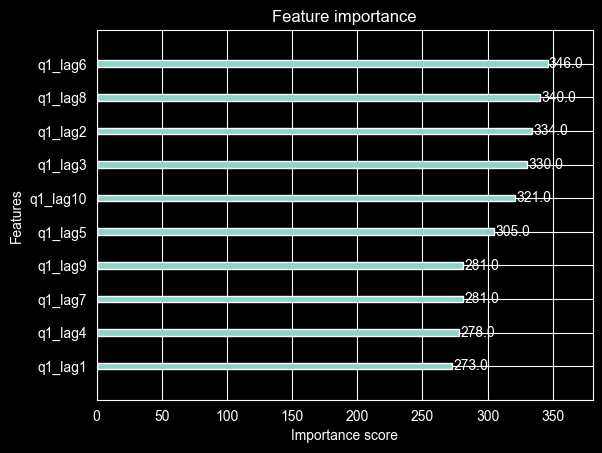

In [39]:
# schauen, was XGBoost genau gemacht hat
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.show()

In [ ]:
# lag1 ist der letzte Eintrag vor dem zu Prognostizierenden. lag10 ist der 10. Eintrag vor dem zu Prognostizierenden.
# je größer "Importance Score", desto wichtiger ist dieser Wert für die Prognose.